<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/notebooks/diffusion_runtime_watchdog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

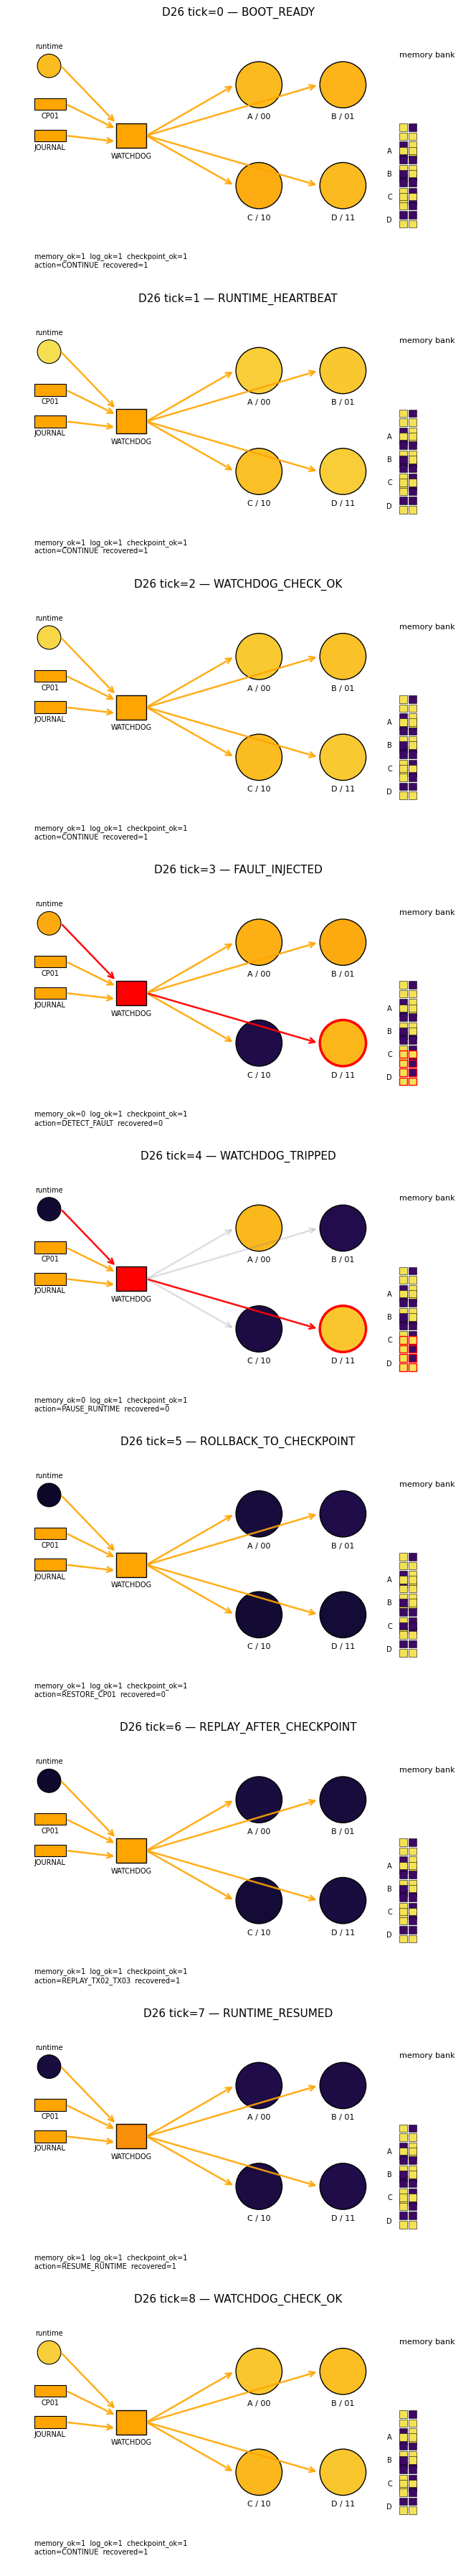

STATE: RUNTIME_WATCHDOG_LOCKED
ticks:                 9
fault cell:            MEM_CELL_D
fault slot:            4
checkpoint id:         CP01
checkpoint after tx:   TX01
replayed transactions: 2
runtime recovered:     True
resume locked:         True
checkpoint hash:       e28bf0576a7d
clean final hash:      a1766a97aacc
final live hash:       a1766a97aacc
final journal hash:    f6c6428b37b3

Runtime watchdog table:


,STATE,TICK,STAGE,ACTION,MEMORY_OK,LOG_OK,CHECKPOINT_OK,LIVE_HASH,EXPECTED_HASH,RECOVERED,RUNNING
0,D26_RUNTIME_WATCHDOG,0,BOOT_READY,CONTINUE,1,1,1,a1766a97aacc,a1766a97aacc,1,1
1,D26_RUNTIME_WATCHDOG,1,RUNTIME_HEARTBEAT,CONTINUE,1,1,1,a1766a97aacc,a1766a97aacc,1,1
2,D26_RUNTIME_WATCHDOG,2,WATCHDOG_CHECK_OK,CONTINUE,1,1,1,a1766a97aacc,a1766a97aacc,1,1
3,D26_RUNTIME_WATCHDOG,3,FAULT_INJECTED,DETECT_FAULT,0,1,1,f599cc9d0415,a1766a97aacc,0,0
4,D26_RUNTIME_WATCHDOG,4,WATCHDOG_TRIPPED,PAUSE_RUNTIME,0,1,1,f599cc9d0415,a1766a97aacc,0,0
5,D26_RUNTIME_WATCHDOG,5,ROLLBACK_TO_CHECKPOINT,RESTORE_CP01,1,1,1,e28bf0576a7d,a1766a97aacc,0,0
6,D26_RUNTIME_WATCHDOG,6,REPLAY_AFTER_CHECKPOINT,REPLAY_TX02_TX03,1,1,1,a1766a97aacc,a1766a97aacc,1,0
7,D26_RUNTIME_WATCHDOG,7,RUNTIME_RESUMED,RESUME_RUNTIME,1,1,1,a1766a97aacc,a1766a97aacc,1,1
8,D26_RUNTIME_WATCHDOG,8,WATCHDOG_CHECK_OK,CONTINUE,1,1,1,a1766a97aacc,a1766a97aacc,1,1



Recovery action table:


,STATE,STEP,SOURCE_HASH,TARGET_HASH,ACTION,MATCH
0,D26_RUNTIME_WATCHDOG,ROLLBACK_TO_CHECKPOINT,f599cc9d0415,e28bf0576a7d,RESTORE_CP01,1
1,D26_RUNTIME_WATCHDOG,REPLAY_AFTER_CHECKPOINT,e28bf0576a7d,a1766a97aacc,REPLAY_TX02_TX03,1



Per-cell recovery table:


,STATE,CELL,CHECKPOINT_SEQUENCE,FAULTED_SEQUENCE,RECOVERED_SEQUENCE,CLEAN_TARGET,RECOVERED_MATCH_CLEAN
0,D26_RUNTIME_WATCHDOG,MEM_CELL_A,10110101,10110101,10110101,10110101,1
1,D26_RUNTIME_WATCHDOG,MEM_CELL_B,11111111,11001100,11001100,11001100,1
2,D26_RUNTIME_WATCHDOG,MEM_CELL_C,01001010,01001010,01001010,01001010,1
3,D26_RUNTIME_WATCHDOG,MEM_CELL_D,00110011,11101011,11100011,11100011,1



Journal hash table:


,STATE,TX_ID,PREV_HASH,TX_HASH
0,D26_RUNTIME_WATCHDOG,TX00,GENESIS0000,154ff8f0008d
1,D26_RUNTIME_WATCHDOG,TX01,154ff8f0008d,4f71d6b9e8dd
2,D26_RUNTIME_WATCHDOG,TX02,4f71d6b9e8dd,1b812293dcf6
3,D26_RUNTIME_WATCHDOG,TX03,1b812293dcf6,f6c6428b37b3



Summary:


,STATE,RESULT,TICKS,FAULT_CELL,FAULT_SLOT,CHECKPOINT_ID,CHECKPOINT_AFTER_TX,REPLAYED_TX,RUNTIME_RECOVERED,RESUME_LOCKED,CHECKPOINT_HASH,CLEAN_FINAL_HASH,FINAL_LIVE_HASH,FINAL_JOURNAL_HASH
0,D26_RUNTIME_WATCHDOG,RUNTIME_WATCHDOG_LOCKED,9,MEM_CELL_D,4,CP01,TX01,2,1,1,e28bf0576a7d,a1766a97aacc,a1766a97aacc,f6c6428b37b3


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hashlib
from copy import deepcopy
from IPython.display import display
from matplotlib.patches import Circle, Rectangle, FancyArrowPatch

# ============================================================
# D26_RUNTIME_WATCHDOG
# Runtime supervisor after boot
#
# Goal:
# boot-ready memory
# -> runtime ticks
# -> watchdog hash checks
# -> inject memory fault
# -> pause runtime
# -> rollback to checkpoint
# -> replay journal after checkpoint
# -> resume clean execution
# ============================================================

np.random.seed(26)

STATE = "D26_RUNTIME_WATCHDOG"

address_map = {
    "00": "MEM_CELL_A",
    "01": "MEM_CELL_B",
    "10": "MEM_CELL_C",
    "11": "MEM_CELL_D",
}

initial_memory = {
    "MEM_CELL_A": "00000000",
    "MEM_CELL_B": "11111111",
    "MEM_CELL_C": "01001010",
    "MEM_CELL_D": "00110011",
}

transactions = [
    {
        "TX_ID": "TX00",
        "OP": "WRITE",
        "WRITER": "A",
        "ADDR": "00",
        "PAYLOAD": "10110101",
        "RESULT": "COMMITTED",
    },
    {
        "TX_ID": "TX01",
        "OP": "WRITE",
        "WRITER": "B",
        "ADDR": "10",
        "PAYLOAD": "01001010",
        "RESULT": "COMMITTED",
    },
    {
        "TX_ID": "TX02",
        "OP": "WRITE",
        "WRITER": "B",
        "ADDR": "01",
        "PAYLOAD": "11001100",
        "RESULT": "COMMITTED",
    },
    {
        "TX_ID": "TX03",
        "OP": "COLLISION_WRITE",
        "WRITER": "A+B",
        "ADDR": "11",
        "PAYLOAD_A": "11100011",
        "PAYLOAD_B": "00011100",
        "WINNER": "A",
        "RESULT": "COLLISION_ARBITRATED",
    },
]

checkpoint_after_tx = "TX01"
checkpoint_id = "CP01"

fault_cell = "MEM_CELL_D"
fault_slot = 4


def seq_to_bits(seq):
    return [int(x) for x in seq]


def bits_to_string(bits):
    return "".join(str(int(x)) for x in bits)


def flip_bit(seq, index):
    bits = seq_to_bits(seq)
    bits[index] = 1 - bits[index]
    return bits_to_string(bits)


def memory_hash(memory):
    payload = "|".join(f"{cell}:{memory[cell]}" for cell in sorted(memory))
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()[:12]


def journal_hash(transactions_used):
    prev = "GENESIS0000"
    rows = []

    for tx in transactions_used:
        fields = [
            prev,
            tx.get("TX_ID", ""),
            tx.get("OP", ""),
            tx.get("WRITER", ""),
            tx.get("ADDR", ""),
            tx.get("PAYLOAD", ""),
            tx.get("PAYLOAD_A", ""),
            tx.get("PAYLOAD_B", ""),
            tx.get("WINNER", ""),
            tx.get("RESULT", ""),
        ]
        raw = "|".join(fields)
        tx_hash = hashlib.sha256(raw.encode("utf-8")).hexdigest()[:12]

        rows.append({
            "TX_ID": tx.get("TX_ID", ""),
            "PREV_HASH": prev,
            "TX_HASH": tx_hash,
        })

        prev = tx_hash

    return prev, rows


def apply_transaction(memory, tx):
    new_memory = deepcopy(memory)
    selected_cell = address_map[tx["ADDR"]]

    if tx["OP"] == "WRITE":
        payload = tx["PAYLOAD"]
        winner = tx["WRITER"]
    elif tx["OP"] == "COLLISION_WRITE":
        winner = tx["WINNER"]
        payload = tx["PAYLOAD_A"] if winner == "A" else tx["PAYLOAD_B"]
    else:
        payload = new_memory[selected_cell]
        winner = "NONE"

    before = new_memory[selected_cell]
    new_memory[selected_cell] = payload
    after = new_memory[selected_cell]

    event = {
        "TX_ID": tx["TX_ID"],
        "OP": tx["OP"],
        "SELECTED_CELL": selected_cell,
        "WINNER": winner,
        "BEFORE_SEQUENCE": before,
        "PAYLOAD_WRITTEN": payload,
        "AFTER_SEQUENCE": after,
        "RESULT": tx["RESULT"],
    }

    return new_memory, event


def run_until(tx_stop_id=None):
    memory = deepcopy(initial_memory)
    tx_events = []

    for tx in transactions:
        memory, event = apply_transaction(memory, tx)
        tx_events.append(event)

        if tx["TX_ID"] == tx_stop_id:
            break

    return memory, tx_events


def replay_after_checkpoint(checkpoint_memory):
    memory = deepcopy(checkpoint_memory)
    replayed = []

    checkpoint_seen = False

    for tx in transactions:
        if checkpoint_seen:
            memory, event = apply_transaction(memory, tx)
            replayed.append(event)

        if tx["TX_ID"] == checkpoint_after_tx:
            checkpoint_seen = True

    return memory, replayed


# ------------------------------------------------------------
# Boot baseline from D25
# ------------------------------------------------------------

checkpoint_memory, checkpoint_events = run_until(checkpoint_after_tx)
clean_final_memory, clean_events = run_until(None)

checkpoint_hash = memory_hash(checkpoint_memory)
clean_final_hash = memory_hash(clean_final_memory)

final_journal_hash, journal_rows = journal_hash(transactions)

live_memory = deepcopy(clean_final_memory)

runtime_rows = []
recovery_rows = []
snapshots = []


def log_tick(tick, phase, stage, action, memory, memory_ok, log_ok, checkpoint_ok, recovered):
    live_hash = memory_hash(memory)
    expected_hash = clean_final_hash

    runtime_rows.append({
        "STATE": STATE,
        "TICK": tick,
        "STAGE": stage,
        "ACTION": action,
        "MEMORY_OK": int(memory_ok),
        "LOG_OK": int(log_ok),
        "CHECKPOINT_OK": int(checkpoint_ok),
        "LIVE_HASH": live_hash,
        "EXPECTED_HASH": expected_hash,
        "RECOVERED": int(recovered),
        "RUNNING": int(action in ["CONTINUE", "RESUME_RUNTIME"]),
    })

    snapshots.append({
        "TICK": tick,
        "PHASE": phase,
        "STAGE": stage,
        "ACTION": action,
        "MEMORY": deepcopy(memory),
        "MEMORY_OK": memory_ok,
        "LOG_OK": log_ok,
        "CHECKPOINT_OK": checkpoint_ok,
        "RECOVERED": recovered,
    })


# ------------------------------------------------------------
# Runtime timeline
# ------------------------------------------------------------

log_tick(
    tick=0,
    phase=0.05,
    stage="BOOT_READY",
    action="CONTINUE",
    memory=live_memory,
    memory_ok=True,
    log_ok=True,
    checkpoint_ok=True,
    recovered=True,
)

log_tick(
    tick=1,
    phase=0.20,
    stage="RUNTIME_HEARTBEAT",
    action="CONTINUE",
    memory=live_memory,
    memory_ok=True,
    log_ok=True,
    checkpoint_ok=True,
    recovered=True,
)

log_tick(
    tick=2,
    phase=0.35,
    stage="WATCHDOG_CHECK_OK",
    action="CONTINUE",
    memory=live_memory,
    memory_ok=True,
    log_ok=True,
    checkpoint_ok=True,
    recovered=True,
)

faulted_memory = deepcopy(live_memory)
faulted_memory[fault_cell] = flip_bit(faulted_memory[fault_cell], fault_slot)

log_tick(
    tick=3,
    phase=0.50,
    stage="FAULT_INJECTED",
    action="DETECT_FAULT",
    memory=faulted_memory,
    memory_ok=False,
    log_ok=True,
    checkpoint_ok=True,
    recovered=False,
)

log_tick(
    tick=4,
    phase=0.62,
    stage="WATCHDOG_TRIPPED",
    action="PAUSE_RUNTIME",
    memory=faulted_memory,
    memory_ok=False,
    log_ok=True,
    checkpoint_ok=True,
    recovered=False,
)

rolled_back_memory = deepcopy(checkpoint_memory)

recovery_rows.append({
    "STATE": STATE,
    "STEP": "ROLLBACK_TO_CHECKPOINT",
    "SOURCE_HASH": memory_hash(faulted_memory),
    "TARGET_HASH": checkpoint_hash,
    "ACTION": "RESTORE_CP01",
    "MATCH": int(memory_hash(rolled_back_memory) == checkpoint_hash),
})

log_tick(
    tick=5,
    phase=0.72,
    stage="ROLLBACK_TO_CHECKPOINT",
    action="RESTORE_CP01",
    memory=rolled_back_memory,
    memory_ok=True,
    log_ok=True,
    checkpoint_ok=True,
    recovered=False,
)

recovered_memory, replayed_events = replay_after_checkpoint(rolled_back_memory)

recovery_rows.append({
    "STATE": STATE,
    "STEP": "REPLAY_AFTER_CHECKPOINT",
    "SOURCE_HASH": memory_hash(rolled_back_memory),
    "TARGET_HASH": clean_final_hash,
    "ACTION": "REPLAY_TX02_TX03",
    "MATCH": int(memory_hash(recovered_memory) == clean_final_hash),
})

log_tick(
    tick=6,
    phase=0.84,
    stage="REPLAY_AFTER_CHECKPOINT",
    action="REPLAY_TX02_TX03",
    memory=recovered_memory,
    memory_ok=True,
    log_ok=True,
    checkpoint_ok=True,
    recovered=True,
)

live_memory = deepcopy(recovered_memory)

log_tick(
    tick=7,
    phase=0.94,
    stage="RUNTIME_RESUMED",
    action="RESUME_RUNTIME",
    memory=live_memory,
    memory_ok=True,
    log_ok=True,
    checkpoint_ok=True,
    recovered=True,
)

log_tick(
    tick=8,
    phase=0.12,
    stage="WATCHDOG_CHECK_OK",
    action="CONTINUE",
    memory=live_memory,
    memory_ok=True,
    log_ok=True,
    checkpoint_ok=True,
    recovered=True,
)


# ------------------------------------------------------------
# Tables
# ------------------------------------------------------------

df_runtime = pd.DataFrame(runtime_rows)
df_recovery = pd.DataFrame(recovery_rows)

cell_rows = []

for cell in sorted(clean_final_memory):
    cell_rows.append({
        "STATE": STATE,
        "CELL": cell,
        "CHECKPOINT_SEQUENCE": checkpoint_memory[cell],
        "FAULTED_SEQUENCE": faulted_memory[cell],
        "RECOVERED_SEQUENCE": recovered_memory[cell],
        "CLEAN_TARGET": clean_final_memory[cell],
        "RECOVERED_MATCH_CLEAN": int(recovered_memory[cell] == clean_final_memory[cell]),
    })

df_cells = pd.DataFrame(cell_rows)

df_journal = pd.DataFrame(journal_rows)
df_journal["STATE"] = STATE
df_journal = df_journal[["STATE", "TX_ID", "PREV_HASH", "TX_HASH"]]

runtime_recovered = int(memory_hash(recovered_memory) == clean_final_hash)
resume_locked = int(df_runtime.iloc[-1]["RUNNING"] == 1 and df_runtime.iloc[-1]["MEMORY_OK"] == 1)

result = (
    "RUNTIME_WATCHDOG_LOCKED"
    if runtime_recovered == 1
    and resume_locked == 1
    and int(df_recovery["MATCH"].min()) == 1
    else "RUNTIME_WATCHDOG_PARTIAL"
)

df_summary = pd.DataFrame([{
    "STATE": STATE,
    "RESULT": result,
    "TICKS": len(df_runtime),
    "FAULT_CELL": fault_cell,
    "FAULT_SLOT": fault_slot,
    "CHECKPOINT_ID": checkpoint_id,
    "CHECKPOINT_AFTER_TX": checkpoint_after_tx,
    "REPLAYED_TX": len(replayed_events),
    "RUNTIME_RECOVERED": runtime_recovered,
    "RESUME_LOCKED": resume_locked,
    "CHECKPOINT_HASH": checkpoint_hash,
    "CLEAN_FINAL_HASH": clean_final_hash,
    "FINAL_LIVE_HASH": memory_hash(live_memory),
    "FINAL_JOURNAL_HASH": final_journal_hash,
}])


# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

def bit_color(bit, intensity=1.0):
    if bit == 1:
        return plt.cm.inferno(0.70 + 0.22 * intensity)
    return plt.cm.inferno(0.07 + 0.12 * intensity)


cell_positions = {
    "MEM_CELL_A": (6.0, 5.7),
    "MEM_CELL_B": (8.0, 5.7),
    "MEM_CELL_C": (6.0, 3.3),
    "MEM_CELL_D": (8.0, 3.3),
}

cell_labels = {
    "MEM_CELL_A": "A / 00",
    "MEM_CELL_B": "B / 01",
    "MEM_CELL_C": "C / 10",
    "MEM_CELL_D": "D / 11",
}


def draw_arrow(ax, start, end, active=True, alert=False):
    if alert:
        color = "red"
        alpha = 0.95
    elif active:
        color = "orange"
        alpha = 0.9
    else:
        color = "gray"
        alpha = 0.25

    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="->",
        mutation_scale=13,
        linewidth=1.8,
        color=color,
        alpha=alpha,
    )
    ax.add_patch(arrow)


def draw_small_bank(ax, x0, y0, memory, title, alert_cell=None):
    ax.text(x0, y0 + 4.05, title, fontsize=8, ha="left", color="black")

    cell_w = 0.18
    cell_h = 0.18
    gap = 0.035

    for row_index, cell in enumerate(sorted(memory)):
        bits = seq_to_bits(memory[cell])

        ax.text(
            x0 - 0.18,
            y0 + (3 - row_index) * 0.55 + 0.12,
            cell[-1],
            fontsize=7,
            ha="right",
            color="black",
        )

        for i, bit in enumerate(bits):
            col = i % 2
            row = i // 2

            x = x0 + col * (cell_w + gap)
            y = y0 + (3 - row_index) * 0.55 + (3 - row) * (cell_h + gap)

            edge = "red" if cell == alert_cell else "black"
            lw = 1.0 if cell == alert_cell else 0.4

            ax.add_patch(Rectangle(
                (x, y),
                cell_w,
                cell_h,
                facecolor=bit_color(bit),
                edgecolor=edge,
                linewidth=lw,
            ))


def draw_cell(ax, cell, seq, active=False, alert=False, phase=0.0):
    x, y = cell_positions[cell]
    bits = seq_to_bits(seq)
    mean_bit = np.mean(bits)

    pulse = 0.5 + 0.5 * np.sin(2 * np.pi * phase)
    visual_value = 0.55 * pulse + 0.45 * mean_bit if active else mean_bit

    bit = 1 if visual_value > 0.5 else 0
    color = bit_color(bit, visual_value)

    edge = "red" if alert else "black"
    lw = 2.5 if alert else 1.0

    ax.add_patch(Circle((x, y), 0.55, facecolor=color, edgecolor=edge, linewidth=lw))
    ax.text(x, y - 0.82, cell_labels[cell], fontsize=8, ha="center", color="black")


def draw_snapshot(ax, snapshot):
    memory = snapshot["MEMORY"]
    phase = snapshot["PHASE"]
    stage = snapshot["STAGE"]
    action = snapshot["ACTION"]
    tick = snapshot["TICK"]

    memory_ok = snapshot["MEMORY_OK"]
    log_ok = snapshot["LOG_OK"]
    checkpoint_ok = snapshot["CHECKPOINT_OK"]
    recovered = snapshot["RECOVERED"]

    alert = not memory_ok
    active = action not in ["PAUSE_RUNTIME"]

    ax.set_facecolor("white")
    ax.set_xlim(0, 11)
    ax.set_ylim(1.0, 7.2)
    ax.set_aspect("equal")
    ax.axis("off")

    ctrl_color = "red" if alert else "orange"

    if action == "RESUME_RUNTIME":
        ctrl_color = plt.cm.inferno(0.75)

    ax.add_patch(Rectangle(
        (2.6, 4.2),
        0.72,
        0.58,
        facecolor=ctrl_color,
        edgecolor="black",
        linewidth=1.0,
    ))

    ax.text(2.96, 3.95, "WATCHDOG", fontsize=7, ha="center", color="black")

    cp_color = "orange" if checkpoint_ok else "red"
    log_color = "orange" if log_ok else "red"

    ax.add_patch(Rectangle(
        (0.65, 5.1),
        0.75,
        0.28,
        facecolor=cp_color,
        edgecolor="black",
        linewidth=0.8,
    ))

    ax.text(1.02, 4.9, checkpoint_id, fontsize=7, ha="center", color="black")

    ax.add_patch(Rectangle(
        (0.65, 4.35),
        0.75,
        0.28,
        facecolor=log_color,
        edgecolor="black",
        linewidth=0.8,
    ))

    ax.text(1.02, 4.15, "JOURNAL", fontsize=7, ha="center", color="black")

    draw_arrow(ax, (1.4, 5.24), (2.6, 4.65), active=checkpoint_ok, alert=not checkpoint_ok)
    draw_arrow(ax, (1.4, 4.49), (2.6, 4.35), active=log_ok, alert=not log_ok)

    heartbeat = 0.5 + 0.5 * np.sin(2 * np.pi * phase)
    hb_color = bit_color(1 if heartbeat > 0.5 else 0, heartbeat)

    ax.add_patch(Circle((1.0, 6.15), 0.28, facecolor=hb_color, edgecolor="black", linewidth=0.8))
    ax.text(1.0, 6.55, "runtime", fontsize=7, ha="center", color="black")

    draw_arrow(ax, (1.28, 6.15), (2.6, 4.78), active=active, alert=alert)

    for cell in sorted(memory):
        cell_alert = alert and cell == fault_cell
        cell_active = active or action in ["RESTORE_CP01", "REPLAY_TX02_TX03", "RESUME_RUNTIME"]

        draw_cell(
            ax,
            cell,
            memory[cell],
            active=cell_active,
            alert=cell_alert,
            phase=phase,
        )

        draw_arrow(
            ax,
            (3.32, 4.49),
            (cell_positions[cell][0] - 0.58, cell_positions[cell][1]),
            active=cell_active,
            alert=cell_alert,
        )

    draw_small_bank(
        ax,
        9.35,
        2.3,
        memory,
        "memory bank",
        alert_cell=fault_cell if alert else None,
    )

    status_text = (
        f"memory_ok={int(memory_ok)}  log_ok={int(log_ok)}  checkpoint_ok={int(checkpoint_ok)}\n"
        f"action={action}  recovered={int(recovered)}"
    )

    ax.text(0.65, 1.35, status_text, fontsize=7, ha="left", color="black")
    ax.set_title(f"D26 tick={tick} — {stage}", fontsize=11, color="black")


fig, axes = plt.subplots(len(snapshots), 1, figsize=(7, 4.0 * len(snapshots)))

for ax, snapshot in zip(axes, snapshots):
    draw_snapshot(ax, snapshot)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

print(f"STATE: {result}")
print(f"ticks:                 {len(df_runtime)}")
print(f"fault cell:            {fault_cell}")
print(f"fault slot:            {fault_slot}")
print(f"checkpoint id:         {checkpoint_id}")
print(f"checkpoint after tx:   {checkpoint_after_tx}")
print(f"replayed transactions: {len(replayed_events)}")
print(f"runtime recovered:     {bool(runtime_recovered)}")
print(f"resume locked:         {bool(resume_locked)}")
print(f"checkpoint hash:       {checkpoint_hash}")
print(f"clean final hash:      {clean_final_hash}")
print(f"final live hash:       {memory_hash(live_memory)}")
print(f"final journal hash:    {final_journal_hash}")

print("\nRuntime watchdog table:")
display(df_runtime)

print("\nRecovery action table:")
display(df_recovery)

print("\nPer-cell recovery table:")
display(df_cells)

print("\nJournal hash table:")
display(df_journal)

print("\nSummary:")
display(df_summary)